In [19]:
import pandas as pd
import numpy as np
from  gestionDataframe import *
from pathlib import Path
import gc
import matplotlib.pyplot as plt
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

### Initialisation/chargement du dataframe

In [20]:
from pathlib import Path

fichier = Path("./data/dataset.csv")

if fichier.is_file():
    df = pd.read_csv("./data/dataset.csv", sep = ";")
else:
    lignes = []
    colonne_name = ["ID ANSSI", "Titre ANSSI", "Type", "Date", "CVE", "Description CVE", "CVSS", "CVSS prédite", "Base severity", "Vecteur de l'attaque", "Complexité de l'attaque", "Privileges requis", "Action utilisateur", "Impact sur la confidentialité", "Impact sur l'intégrité", "Impact sur la disponibilité", "CWE", "EPSS", "EPSS prédite", "Lien CVE", "Lien solution", "Description CWE", "Editeur", "Produit", "Versions affectées"]
    tab_alertes = os.listdir("./data/alertes")
    for fichier_anssi in tab_alertes:
        json_anssi = obtenir_json(fichier_anssi, "alerte")
        dico_anssi, tab_cve = create_dico_ANSSI(json_anssi)
        for cve in tab_cve:
            dico_cve = create_dico_CVE(cve)
            if dico_cve is not None:
                new_ligne = dico_anssi | dico_cve
                lignes.append(new_ligne)
    tab_avis = os.listdir("./data/Avis")
    for fichier_anssi in tab_avis:
        json_anssi = obtenir_json(fichier_anssi, "avis")
        dico_anssi, tab_cve = create_dico_ANSSI(json_anssi)
        for cve in tab_cve:
            dico_cve = create_dico_CVE(cve)
            if dico_cve is not None:
                new_ligne = dico_anssi | dico_cve
                lignes.append(new_ligne)
    df = pd.DataFrame(lignes)
    df = df.reindex(columns=colonne_name)

### Affichage d'une partie du dataset

In [21]:
df.head(20)

,ID ANSSI,Titre ANSSI,Type,Date,CVE,Description CVE,CVSS,Base severity,Vecteur de l'attaque,Complexité de l'attaque,...,CWE,EPSS,Lien CVE,Lien solution,Description CWE,Editeur,Produit,Versions affectées,CVSS prédite,EPSS prédite
0,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02T00:00:00.000000,CVE-2021-20016,A SQL-Injection vulnerability in the SonicWall...,NaN,NaN,NaN,NaN,...,CWE-89,0.79818,https://www.cve.org/CVERecord?id=CVE-2021-20016,https://psirt.global.sonicwall.com/vuln-detail...,CWE-89: Improper Neutralization of Special Ele...,SonicWall,SonicWall SMA100,SMA100 build version 10.x,NaN,0.79818
1,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02T00:00:00.000000,CVE-2014-6271,GNU Bash through 4.3 processes trailing string...,NaN,NaN,NaN,NaN,...,NaN,0.94220,https://www.cve.org/CVERecord?id=CVE-2014-6271,http://lists.opensuse.org/opensuse-security-an...,NaN,NaN,NaN,NaN,NaN,0.94220
2,CERTFR-2021-ALE-002,[MàJ] Vulnérabilité dans Google Chrome et Micr...,Alerte,2021-02-05T00:00:00.000000,CVE-2021-21148,Heap buffer overflow in V8 in Google Chrome pr...,NaN,NaN,NaN,NaN,...,NaN,0.19904,https://www.cve.org/CVERecord?id=CVE-2021-21148,https://lists.fedoraproject.org/archives/list/...,Heap buffer overflow,Google,Chrome,unspecified,NaN,0.19904
3,CERTFR-2021-ALE-003,[MàJ] Vulnérabilité dans VMware vCenter Server,Alerte,2021-02-25T00:00:00.000000,CVE-2021-21972,The vSphere Client (HTML5) contains a remote c...,NaN,NaN,NaN,NaN,...,NaN,0.93821,https://www.cve.org/CVERecord?id=CVE-2021-21972,https://www.vmware.com/security/advisories/VMS...,Remote code execution vulnerability,"n/a, n/a","VMware vCenter Server, VMware Cloud Foundation","7.x before 7.0 U1c, 6.7 before 6.7 U3l, 6.5 be...",NaN,0.93821
4,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-26858,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,NaN,0.55064,https://www.cve.org/CVERecord?id=CVE-2021-26858,https://portal.msrc.microsoft.com/en-US/securi...,Remote Code Execution,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...","Microsoft Exchange Server 2019, Microsoft Exc...","15.02.0, 15.00.0, 15.02.0, 15.01.0, 15.00.0, 1...",7.8,0.55064
5,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-27078,Microsoft Exchange Server Remote Code Executio...,9.1,CRITICAL,NETWORK,LOW,...,NaN,0.32551,https://www.cve.org/CVERecord?id=CVE-2021-27078,https://portal.msrc.microsoft.com/en-US/securi...,Remote Code Execution,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...",Microsoft Exchange Server 2016 Cumulative Upda...,"15.01.0, 15.02.0, 15.00.0, 15.02.0, 15.01.0",9.1,0.32551
6,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-26857,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,NaN,0.34542,https://www.cve.org/CVERecord?id=CVE-2021-26857,https://portal.msrc.microsoft.com/en-US/securi...,Remote Code Execution,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...",Microsoft Exchange Server 2016 Cumulative Upda...,"15.01.0, 15.02.0, 15.02.0, 15.00.0, 15.02.0, 1...",7.8,0.34542
7,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-26855,Microsoft Exchange Server Remote Code Executio...,9.1,CRITICAL,NETWORK,LOW,...,NaN,0.94351,https://www.cve.org/CVERecord?id=CVE-2021-26855,https://portal.msrc.microsoft.com/en-US/securi...,Remote Code Execution,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...",Microsoft Exchange Server 2016 Cumulative Upda...,"15.01.0, 15.02.0, 15.02.0, 15.00.0, 15.02.0, 1...",9.1,0.94351
8,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-27065,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,NaN,0.94282,https://www.cve.org/CVERecord?id=CVE-2021-

### Affichage de toutes les colonnes

In [22]:
print(df.columns)

Index(['ID ANSSI', 'Titre ANSSI', 'Type', 'Date', 'CVE', 'Description CVE',
       'CVSS', 'Base severity', 'Vecteur de l'attaque',
       'Complexité de l'attaque', 'Privileges requis', 'Action utilisateur',
       'Impact sur la confidentialité', 'Impact sur l'intégrité',
       'Impact sur la disponibilité', 'CWE', 'EPSS', 'Lien CVE',
       'Lien solution', 'Description CWE', 'Editeur', 'Produit',
       'Versions affectées', 'CVSS prédite', 'EPSS prédite'],
      dtype='str')


# Model Machine learning :

L’objectif de ce notebook est de compléter les valeurs manquantes du dataset afin de pouvoir prioriser les vulnérabilités. Nous cherchons d’abord à prédire les valeurs CVSS manquantes, puis les valeurs EPSS manquantes. Le CVSS représente la gravité technique d’une vulnérabilité, tandis que l’EPSS représente sa probabilité d’exploitation.

Nous avons prepare et encode les donnees de differentes manieres en fonction de leur type. Les variables catégorielles comme l’éditeur, le produit, le type ou le CWE sont transformées avec un OneHotEncoder plutot qu'avec un LabelEncoder pour eviter d'influencer les modeles par le code des labels. Les colonnes textuelles comme le titre, la description CVE et la description CWE sont transformées avec un TF-IDF, ce qui permet de représenter les mots importants sous forme numérique. Nous ne pouvons pas conserver tous les mots car cela ferait trop de donnees donc on decide de conserver seulement 500 mots.

Les dates sont également transformées en variables simples, comme l’année et le mois, pour conserver une information temporelle exploitable par le modèle. Les valeurs EPSS manquantes sont temporairement remplacées par la médiane afin de pouvoir utiliser cette variable comme information d’entrée.

Pour rendre le modèle CVSS plus réaliste, nous retirons certaines colonnes directement liées au calcul du score, comme Base Severity, Attack Vector ou les impacts confidentialité / intégrité / disponibilité. Cela permet d’éviter une fuite d’information et de ne pas surestimer les performances du modèle.

Pour l’EPSS, nous utilisons également un modèle de régression, car l’EPSS est une valeur numérique comprise entre 0 et 1.

Enfin, une fois les valeurs CVSS et EPSS complétées, un score de risque est calculé en combinant les deux informations. Le CVSS est pondéré à 60 %, car il représente la gravité technique, et l’EPSS à 40 %, car il représente la probabilité d’exploitation. Ce score permet de classer les vulnérabilités en niveaux de priorité : LOW, MEDIUM, HIGH et CRITICAL.

Le code principal est séparé dans un fichier `utils.py` afin de rendre le notebook plus lisible et de pouvoir réutiliser les fonctions sur de nouvelles données.

### 1) Importations

In [23]:
from ML import *
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingRegressor


### 2) Création des encodeurs

In [24]:
path_OH = Path("./model/OneHot_encoder.pkl")
path_TFGBR = Path("./model/TfIdf_vectorizer_GBR.pkl")
path_TFKM = Path("./model/TfIdf_vectorizer_KM.pkl")
df_encoded = df.copy()
categorical_cols = ["Type", "Editeur", "Produit", "CWE", "Base severity", "Vecteur de l'attaque", "Complexité de l'attaque",
    "Privileges requis", "Action utilisateur", "Impact sur la confidentialité", "Impact sur l'intégrité",
    "Impact sur la disponibilité"]
texts_cols = ["Titre ANSSI", "Description CVE", "Description CWE"]
df_encoded[texts_cols] = df_encoded[texts_cols].fillna("")
df_encoded["text_for_tfidf"] = df_encoded[texts_cols].astype(str).agg(" ".join, axis=1)
if not path_OH.is_file():
    encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
    encoder.fit(df[categorical_cols])
    with open("./model/OneHot_encoder.pkl", "wb") as fichier:
        pickle.dump(encoder, fichier)
if not path_TFGBR.is_file():
    vectorizer = TfidfVectorizer(stop_words='english', max_features=500, ngram_range=(1,2))
    vectorizer.fit(df_encoded["text_for_tfidf"])
    with open("./model/TfIdf_vectorizer_GBR.pkl", "wb") as fichier:
        pickle.dump(vectorizer, fichier)
if not path_TFKM.is_file():
    vectorizer = TfidfVectorizer(stop_words='english', max_features=500, ngram_range=(1,2))
    vectorizer.fit(df["Description CVE"].fillna(""))
    with open("./model/TfIdf_vectorizer_KM.pkl", "wb") as fichier:
        pickle.dump(vectorizer, fichier)


### 2) Chargement et encodage du dataset

In [25]:
dataset_encoded = encode_dataset(df)
print("Shape :", dataset_encoded.shape)
print("Valeurs manquantes restantes :")
print(dataset_encoded.isna().sum().sort_values(ascending=False).head(10))
df.head(20)

Shape : (125372, 7750)
Valeurs manquantes restantes :
CVSS prédite              96091
CVSS                      96091
EPSS                        763
EPSS prédite                763
Editeur_5VTechnologies        0
Editeur_7-Zip                 0
Editeur_ADOdb                 0
Editeur_AMD                   0
Editeur_AMD,  AMD             0
Editeur_AMD, AMD              0
dtype: int64


,ID ANSSI,Titre ANSSI,Type,Date,CVE,Description CVE,CVSS,Base severity,Vecteur de l'attaque,Complexité de l'attaque,...,CWE,EPSS,Lien CVE,Lien solution,Description CWE,Editeur,Produit,Versions affectées,CVSS prédite,EPSS prédite
0,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02T00:00:00.000000,CVE-2021-20016,A SQL-Injection vulnerability in the SonicWall...,NaN,NaN,NaN,NaN,...,CWE-89,0.79818,https://www.cve.org/CVERecord?id=CVE-2021-20016,https://psirt.global.sonicwall.com/vuln-detail...,CWE-89: Improper Neutralization of Special Ele...,SonicWall,SonicWall SMA100,SMA100 build version 10.x,NaN,0.79818
1,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02T00:00:00.000000,CVE-2014-6271,GNU Bash through 4.3 processes trailing string...,NaN,NaN,NaN,NaN,...,NaN,0.94220,https://www.cve.org/CVERecord?id=CVE-2014-6271,http://lists.opensuse.org/opensuse-security-an...,NaN,NaN,NaN,NaN,NaN,0.94220
2,CERTFR-2021-ALE-002,[MàJ] Vulnérabilité dans Google Chrome et Micr...,Alerte,2021-02-05T00:00:00.000000,CVE-2021-21148,Heap buffer overflow in V8 in Google Chrome pr...,NaN,NaN,NaN,NaN,...,NaN,0.19904,https://www.cve.org/CVERecord?id=CVE-2021-21148,https://lists.fedoraproject.org/archives/list/...,Heap buffer overflow,Google,Chrome,unspecified,NaN,0.19904
3,CERTFR-2021-ALE-003,[MàJ] Vulnérabilité dans VMware vCenter Server,Alerte,2021-02-25T00:00:00.000000,CVE-2021-21972,The vSphere Client (HTML5) contains a remote c...,NaN,NaN,NaN,NaN,...,NaN,0.93821,https://www.cve.org/CVERecord?id=CVE-2021-21972,https://www.vmware.com/security/advisories/VMS...,Remote code execution vulnerability,"n/a, n/a","VMware vCenter Server, VMware Cloud Foundation","7.x before 7.0 U1c, 6.7 before 6.7 U3l, 6.5 be...",NaN,0.93821
4,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-26858,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,NaN,0.55064,https://www.cve.org/CVERecord?id=CVE-2021-26858,https://portal.msrc.microsoft.com/en-US/securi...,Remote Code Execution,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...","Microsoft Exchange Server 2019, Microsoft Exc...","15.02.0, 15.00.0, 15.02.0, 15.01.0, 15.00.0, 1...",7.8,0.55064
5,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-27078,Microsoft Exchange Server Remote Code Executio...,9.1,CRITICAL,NETWORK,LOW,...,NaN,0.32551,https://www.cve.org/CVERecord?id=CVE-2021-27078,https://portal.msrc.microsoft.com/en-US/securi...,Remote Code Execution,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...",Microsoft Exchange Server 2016 Cumulative Upda...,"15.01.0, 15.02.0, 15.00.0, 15.02.0, 15.01.0",9.1,0.32551
6,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-26857,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,NaN,0.34542,https://www.cve.org/CVERecord?id=CVE-2021-26857,https://portal.msrc.microsoft.com/en-US/securi...,Remote Code Execution,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...",Microsoft Exchange Server 2016 Cumulative Upda...,"15.01.0, 15.02.0, 15.02.0, 15.00.0, 15.02.0, 1...",7.8,0.34542
7,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-26855,Microsoft Exchange Server Remote Code Executio...,9.1,CRITICAL,NETWORK,LOW,...,NaN,0.94351,https://www.cve.org/CVERecord?id=CVE-2021-26855,https://portal.msrc.microsoft.com/en-US/securi...,Remote Code Execution,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...",Microsoft Exchange Server 2016 Cumulative Upda...,"15.01.0, 15.02.0, 15.02.0, 15.00.0, 15.02.0, 1...",9.1,0.94351
8,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-27065,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,NaN,0.94282,https://www.cve.org/CVERecord?id=CVE-2021-

## a) Modéle pour la prédiction du CVSS

### 1) Creation des test/split set pour modele CVSS

In [26]:
cols_to_remove = get_cvss_columns(dataset_encoded)
print("Nombre de colonnes retirées :", len(cols_to_remove))

Nombre de colonnes retirées : 35


In [27]:
df_cvss = dataset_encoded.dropna(subset=["CVSS prédite", "EPSS prédite"])
X_cvss = df_cvss.drop(columns=["CVSS", "EPSS", "CVSS prédite", "EPSS prédite"] + cols_to_remove)
y_cvss = df_cvss["CVSS"]
X_train_cvss, X_test_cvss, y_train_cvss, y_test_cvss = train_test_split(
    X_cvss,
    y_cvss,
    test_size=0.2,
    random_state=42
)
print(X_train_cvss.shape)
print(X_test_cvss.shape)
print(y_train_cvss.shape)
print(y_test_cvss.shape)
print("NaN dans X_train :", X_train_cvss.isna().sum().sum())
del df_cvss
del X_cvss
del y_cvss
gc.collect()



(23407, 7711)
(5852, 7711)
(23407,)
(5852,)
NaN dans X_train : 0


0

### 2) Entrainement du meilleur modele cvss

In [28]:
path = Path("./model/model_cvss.pkl")
if not path.is_file():
    model_cvss = GradientBoostingRegressor(
        random_state=42,
        subsample=1.0,
        n_estimators=150,
        min_samples_leaf=10,
        max_depth=4,
        learning_rate=0.1
    )
    model_cvss.fit(X_train_cvss, y_train_cvss)
    with open("./model/model_cvss.pkl", "wb") as fichier:
        pickle.dump(model_cvss, fichier)
else:
    with open("./model/model_cvss.pkl", "rb") as fichier:
        model_cvss = pickle.load(fichier)

### 3) Evaluation du modele

Sur le test :

In [29]:
y_pred_test = model_cvss.predict(X_test_cvss)
mae_test = mean_absolute_error(y_test_cvss, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test_cvss, y_pred_test))
r2_test = r2_score(y_test_cvss, y_pred_test)
print("Performance sur le dataset de test")
print(f"MAE : {mae_test}")
print(f"RMSE : {rmse_test}")
print(f"R² : {r2_test}")




Performance sur le dataset de test
MAE : 0.8815489614664119
RMSE : 1.1929492221474025
R² : 0.492648438884691


Sur le train :

In [30]:
y_pred_train_cvss = model_cvss.predict(X_train_cvss)
mae_train_cvss = mean_absolute_error(y_train_cvss, y_pred_train_cvss)
rmse_train_cvss = np.sqrt(mean_squared_error(y_train_cvss, y_pred_train_cvss))
r2_train_cvss = r2_score(y_train_cvss, y_pred_train_cvss)
print("Performance sur le dataset de train")
print(f"MAE : {mae_train_cvss}")
print(f"RMSE : {rmse_train_cvss}")
print(f"R² : {r2_train_cvss}")

Performance sur le dataset de train
MAE : 0.8588334865998493
RMSE : 1.1476909154547894
R² : 0.54271047244166


In [31]:
del y_pred_test
del y_pred_train_cvss
del X_train_cvss
del X_test_cvss
del y_train_cvss
del y_test_cvss
gc.collect()

0

Le modèle ne semble donc pas overfitter

### 4) Completion cvss manquants

In [32]:
mask_cvss_missing = df["CVSS prédite"].isna()
if mask_cvss_missing.sum() > 0:
    X_cvss_missing = dataset_encoded.loc[mask_cvss_missing].drop(
        columns=["CVSS", "EPSS", "EPSS prédite", "CVSS prédite"] + cols_to_remove
    )
    df.loc[mask_cvss_missing, "CVSS prédite"] = model_cvss.predict(X_cvss_missing)
    df["CVSS prédite"] = df["CVSS prédite"].clip(0, 10)
del X_cvss_missing
del mask_cvss_missing
gc.collect()

0

## B) Prediction des EPSS manquants

### 1) Creation des test/split set pour modele EPSS

In [65]:
df_epss = dataset_encoded.dropna(subset=["EPSS prédite", "CVSS prédite"])
X_epss = df_epss.drop(
    columns=["EPSS", "CVSS", "CVSS prédite", "EPSS prédite"] + cols_to_remove
)
y_epss = df_epss["EPSS"]
X_train_epss, X_test_epss, y_train_epss, y_test_epss = train_test_split(
    X_epss,
    y_epss,
    test_size=0.2,
    random_state=42
)

print(X_train_epss.shape)
print(X_test_epss.shape)
print(y_train_epss.shape)
print(y_test_epss.shape)

print("NaN dans X_train_epss :", X_train_epss.isna().sum().sum())

(23407, 7711)
(5852, 7711)
(23407,)
(5852,)
NaN dans X_train_epss : 0


### 2) Entrainement du modele EPSS

In [66]:
path = Path("./model/model_epss.pkl")
if not path.is_file():
    model_epss = GradientBoostingRegressor(
        random_state=42,
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        min_samples_leaf=5,
        subsample=1.0
    )
    model_epss.fit(X_train_epss, y_train_epss)
    with open("./model/model_epss.pkl", "wb") as fichier:
        pickle.dump(model_epss, fichier)
else:
    with open(path, "rb") as fichier:
        model_epss = pickle.load(fichier)

### 3) Evaluation du modele

Sur le dataset de test :

In [37]:
y_pred_test_epss = model_epss.predict(X_test_epss)
mae_test_epss = mean_absolute_error(y_test_epss, y_pred_test_epss)
rmse_test_epss = np.sqrt(mean_squared_error(y_test_epss, y_pred_test_epss))
r2_test_epss = r2_score(y_test_epss, y_pred_test_epss)
print("Performance sur le dataset de test")
print(f"MAE : {mae_test_epss}")
print(f"RMSE : {rmse_test_epss}")
print(f"R² : {r2_test_epss}")

Performance sur le dataset de test
MAE : 0.03173545819477747
RMSE : 0.0913665042465555
R² : 0.3596577883245089


Sur le dataset de train :

In [38]:
y_pred_train_epss = model_epss.predict(X_train_epss)
mae_train_epss = mean_absolute_error(y_train_epss, y_pred_train_epss)
rmse_train_epss = np.sqrt(mean_squared_error(y_train_epss, y_pred_train_epss))
r2_train_epss = r2_score(y_train_epss, y_pred_train_epss)
print("Performance sur le dataset de test")
print(f"MAE : {mae_train_epss}")
print(f"RMSE : {rmse_train_epss}")
print(f"R² : {r2_train_epss}")

Performance sur le dataset de test
MAE : 0.032571030096415494
RMSE : 0.09497844274522803
R² : 0.35671317344596376


### 4) Completion epss manquants

In [39]:
mask_epss_missing = df["EPSS"].isna()
if mask_epss_missing.sum() > 0:
    X_epss_missing = dataset_encoded.loc[mask_epss_missing].drop(
        columns=["EPSS", "CVSS", "CVSS prédite", "EPSS prédite"] + cols_to_remove
    )
    df.loc[mask_epss_missing, "EPSS prédite"] = model_epss.predict(X_epss_missing)
    df["EPSS prédite"] = df["EPSS prédite"].clip(0, 1)

### C) Creation du score de risque

In [40]:
df["score de risque"] = (0.6 * (df["CVSS prédite"] / 10) + 0.4 * df["EPSS prédite"])
df[[
    "CVE",
    "CVSS",
    "CVSS prédite",
    "EPSS",
    "EPSS prédite",
    "score de risque"
]].head(20)


,CVE,CVSS,CVSS prédite,EPSS,EPSS prédite,score de risque
0,CVE-2021-20016,NaN,7.603163,0.79818,0.79818,0.775462
1,CVE-2014-6271,NaN,9.156742,0.94220,0.94220,0.926285
2,CVE-2021-21148,NaN,7.165453,0.19904,0.19904,0.509543
3,CVE-2021-21972,NaN,8.615376,0.93821,0.93821,0.892207
4,CVE-2021-26858,7.8,7.800000,0.55064,0.55064,0.688256
5,CVE-2021-27078,9.1,9.100000,0.32551,0.32551,0.676204
6,CVE-2021-26857,7.8,7.800000,0.34542,0.34542,0.606168
7,CVE-2021-26855,9.1,9.100000,0.94351,0.94351,0.923404
8,CVE-2021-27065,7.8,7.800000,0.94282,0.94282,0.845128
9,CVE-2021-26412,9.1,9.100000,0.24204,0.24204,0.642816


In [41]:
del df_epss
del X_train_epss
del y_train_epss
del X_test_epss
del y_test_epss
del y_pred_test_epss
del y_pred_train_epss
del y_epss
del X_epss
gc.collect()

0

## d) Kmeans (non supervisé):

In [43]:
tf_idf = get_TfIdf_KM_vectorizer().transform(df["Description CVE"].fillna(""))
mean_tfidf = np.asarray(tf_idf.mean(axis=0)).ravel()
top_indices = np.argsort(mean_tfidf)[::-1][:10000]
tf_idf_filtered = tf_idf[:, top_indices]                                         # On filtre avant toarray pour améliorer la compléxité
vectorizer = get_TfIdf_KM_vectorizer()
vocab_filtered = vectorizer.get_feature_names_out()[top_indices]
df_tfidf = pd.DataFrame(tf_idf_filtered.toarray(), columns=vocab_filtered)       # toarray() transforme cahque ligne en liste. On obtient une matrice avec toutes les descriptions
df_tfidf.head()

,kernel,vulnerability,linux,following,fix,linux kernel,resolved,following vulnerability,kernel following,vulnerability resolved,...,66,fc,48 8b,slub,mm slub,c3,kasan common,f8,fb fb,fc fc
0,0.0,0.269102,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.080593,0.0,0.0,0.24504,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.000000,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.068795,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.178129,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Silhouette Score

In [44]:
results = []

for k in range(2,100):                                                                              # On teste différentes valeurs de k
    KMean = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=10)                               # On applique Kmeans par batch pour limiter le temps d'éxécution
    labels = KMean.fit_predict(tf_idf)                                                              # On applique le KMeans sur la mtrice tf_idf
    echantillon = np.random.choice(tf_idf.shape[0], size=5000, replace=False)                       # Échantillon de 5000 points pour ne pas faire exploser le temps de calcul
    score = silhouette_score(tf_idf[echantillon], labels[echantillon], metric='cosine')             # On calcule le silhouette score avec k clusters pour 5000

    results.append({"k": k, "inertia": KMean.inertia_, "silhouette": score})
    print(f"k={k} → inertie={KMean.inertia_:.0f} | silhouette={score:.4f}")

df_results = pd.DataFrame(results)                                                                  # On crée un DF pour les résultats

best_k = df_results.loc[df_results["silhouette"].idxmax(), "k"]                                     # On récupére le meilleur k
print(f"Meilleur K : {best_k} (silhouette={df_results['silhouette'].max():.4f})")

k=2 → inertie=114399 | silhouette=0.0595
k=3 → inertie=112329 | silhouette=0.0590
k=4 → inertie=110547 | silhouette=0.0600
k=5 → inertie=110451 | silhouette=0.0479
k=6 → inertie=107878 | silhouette=0.0540
k=7 → inertie=106329 | silhouette=0.0595
k=8 → inertie=105545 | silhouette=0.0656
k=9 → inertie=103805 | silhouette=0.0720
k=10 → inertie=109251 | silhouette=-0.0224
k=11 → inertie=104497 | silhouette=0.0488
k=12 → inertie=103173 | silhouette=0.0518
k=13 → inertie=100403 | silhouette=0.0947
k=14 → inertie=101575 | silhouette=0.0544
k=15 → inertie=99109 | silhouette=0.0965
k=16 → inertie=100102 | silhouette=0.0488
k=17 → inertie=99693 | silhouette=0.0641
k=18 → inertie=99365 | silhouette=0.0536
k=19 → inertie=96635 | silhouette=0.0985
k=20 → inertie=98551 | silhouette=0.0695
k=21 → inertie=97689 | silhouette=0.0584
k=22 → inertie=97957 | silhouette=0.0666
k=23 → inertie=97121 | silhouette=0.0583
k=24 → inertie=94246 | silhouette=0.1127
k=25 → inertie=95283 | silhouette=0.0707
k=26 → in

### Création et entrainement du modele

In [64]:
path_KM = Path("./model/model_kmean")
if not path_KM.is_file():
    model_kmean = MiniBatchKMeans(n_clusters=best_k, random_state=42)
    model_kmean.fit(tf_idf)
    with open(path_KM, "wb") as fichier:
        pickle.dump(model_kmean, fichier)
else:
    with open(path_KM, "rb") as fichier:
        model_kmean = pickle.load(fichier)
df["cluster"] = model_kmean.labels_
    

### Graphique des clusters

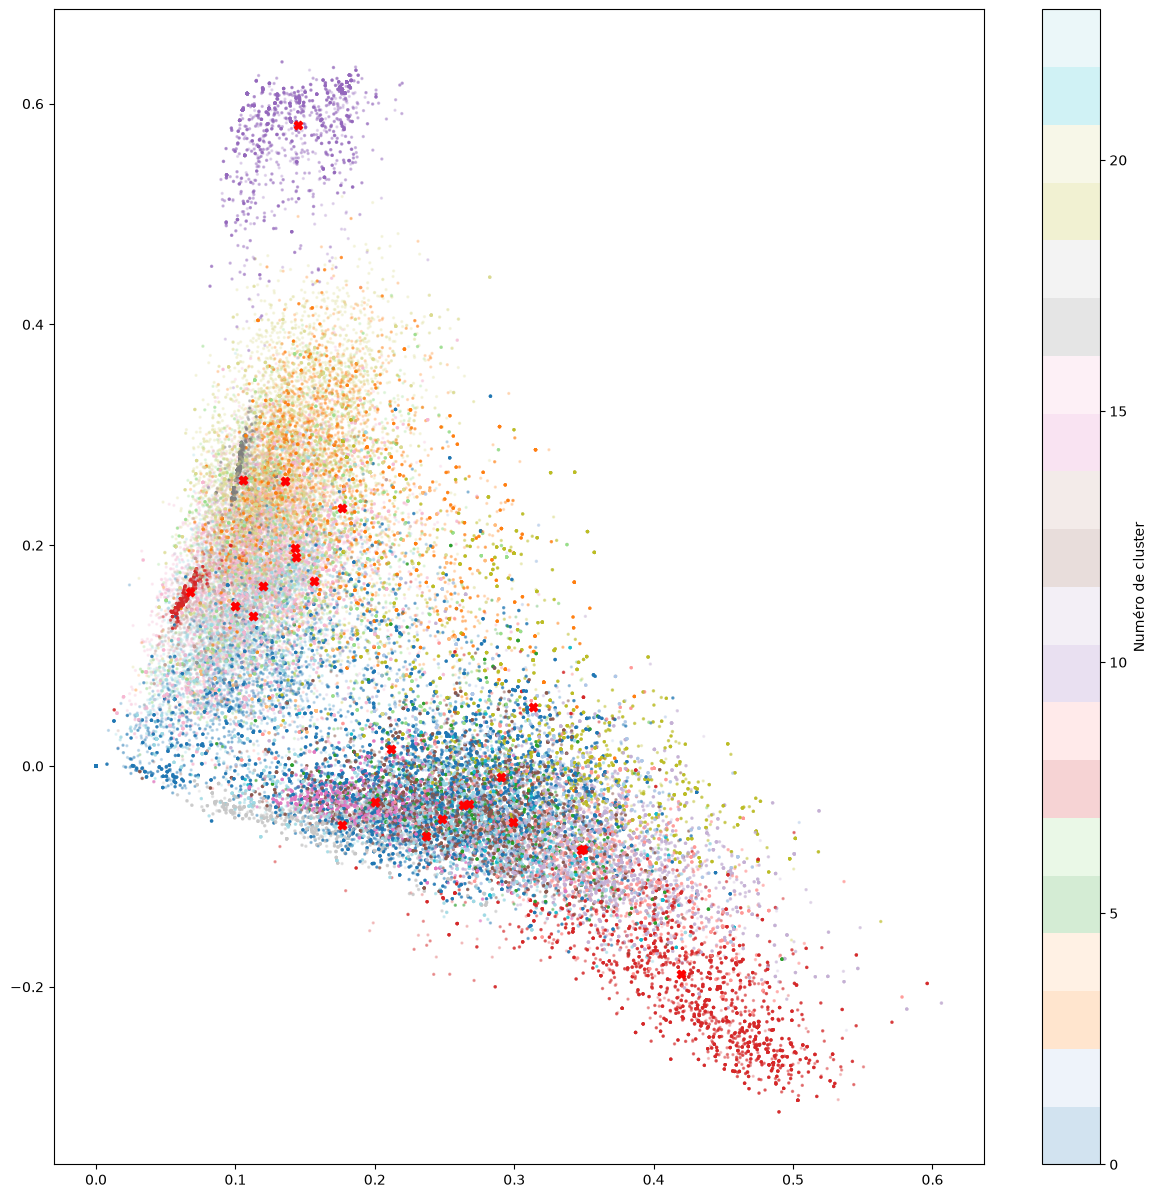

In [46]:
svd = TruncatedSVD(n_components=2, random_state=42)
tf_idf_2d = svd.fit_transform(tf_idf)                        # Réduit toutes les 125K lignes en 2D
centroids_2d = svd.transform(model_kmean.cluster_centers_)         # (best_k x 2)

plt.figure(figsize=(15, 15))
scatter = plt.scatter(
    tf_idf_2d[:, 0],                                        # Toutes les lignes, colonne 0
    tf_idf_2d[:, 1],                                        # Toutes les lignes, colonne 1
    c=df["cluster"].values,                                 # Couleur = numéro de cluster
    cmap='tab20',
    alpha=0.2,                                              # On augmente la transaparence des points pour mieux voir les clusters
    s=2                                                     # Points très petits pour 125K points
)


plt.scatter(centroids_2d[:, 0],centroids_2d[:, 1],c='red',marker='X')

plt.colorbar(scatter, label="Numéro de cluster")
plt.savefig("clusters_kmeans.png", dpi=150)
plt.show()

### Prédire la classe

In [47]:
nouvelle_description = get_TfIdf_KM_vectorizer().transform(["Buffer overflow in Apache allowing remote code execution"])
nd_predict = model_kmean.predict(nouvelle_description)[0]
print(nd_predict)

20


### Trouver CVE équivalentes

In [48]:
cluster_mask = (df["cluster"] == nd_predict).values                                     # On crée un mask pour récuperer les descriptions du meme cluster
cluster_vecs = tf_idf[cluster_mask]

similarities = cosine_similarity(nouvelle_description, cluster_vecs).ravel()            # cosine_similarity calcule la similitude entre la nouvelle description et toutes les descriptions du cluster.
                                                                                        # ravel() transforme le résultat en 1D

top_indices = np.argsort(similarities)[::-1][:2]                                        # argsort donne les elements avec la similitude du plus bas au plus haut et on inverse avec [::-1].
                                                                                        # [:2] nous donne les 2premiéres colonne

results = df[cluster_mask].iloc[top_indices].copy()                                     # On récupére les lignes de top_indices

results

,ID ANSSI,Titre ANSSI,Type,Date,CVE,Description CVE,CVSS,Base severity,Vecteur de l'attaque,Complexité de l'attaque,...,Lien CVE,Lien solution,Description CWE,Editeur,Produit,Versions affectées,CVSS prédite,EPSS prédite,score de risque,cluster
102,CERTFR-2023-ALE-008,[MàJ] Vulnérabilité dans Citrix NetScaler ADC ...,Alerte,2023-07-19T00:00:00.000000,CVE-2023-3519,Unauthenticated remote code execution\n,9.8,CRITICAL,NETWORK,LOW,...,https://www.cve.org/CVERecord?id=CVE-2023-3519,https://support.citrix.com/article/CTX561482/c...,CWE-94 Improper Control of Generation of Code ...,"Citrix, Citrix","NetScaler ADC , NetScaler Gateway","13.1, 13.0, 13.1-FIPS, 12.1-FIPS, 12.1-NDcPP, ...",9.8,0.93993,0.963972,20
9918,CERTFR-2023-AVI-0854,Multiples vulnérabilités dans Moodle,Avis,2023-10-17T00:00:00.000000,CVE-2023-5540,A remote code execution risk was identified in...,4.7,MEDIUM,NETWORK,LOW,...,https://www.cve.org/CVERecord?id=CVE-2023-5540,http://git.moodle.org/gw?p=moodle.git&a=search...,Improper Control of Generation of Code ('Code ...,Unknow,Unknow,"4.2.0, 4.1.0, 4.0.0, 3.11.0, 0",4.7,0.01832,0.289328,20


Interprétation et Visualisation :

Ce notebook analyse le dataset enrichi (CVE, CVSS, EPSS, risk score) pour identifier les vulnérabilités critiques, les produits les plus impactés et les menaces à forte probabilité d'exploitation.

In [49]:
df_visu = df.copy()

df_visu["Date"] = pd.to_datetime(df_visu["Date"], errors="coerce")
df_visu["CVSS"] = pd.to_numeric(df_visu["CVSS"],           errors="coerce")
df_visu["EPSS"] = pd.to_numeric(df_visu["EPSS"],           errors="coerce")
df_visu["CVSS prédite"] = pd.to_numeric(df_visu["CVSS prédite"], errors="coerce")
df_visu["EPSS prédite"] = pd.to_numeric(df_visu["EPSS prédite"], errors="coerce")
df_visu["score de risque"]     = pd.to_numeric(df_visu["score de risque"],     errors="coerce")

# Nettoyage colonnes éditeur / produit (peut contenir "Linux, Linux")
df_visu["Editeur_clean"] = df_visu["Editeur"].str.split(",").str[0].str.strip()
df_visu["Produit_clean"] = df_visu["Produit"].str.split(",").str[0].str.strip()

print(f"Shape : {df_visu.shape[0]} lignes, {df_visu.shape[1]} colonnes")
print(f"Période : {df_visu['Date'].min().date()} → {df_visu['Date'].max().date()}")
print(f"CVE uniques : {df_visu['CVE'].nunique()}")
df.head()


Shape : 125372 lignes, 29 colonnes
Période : 2021-02-02 → 2026-06-09
CVE uniques : 36795


,ID ANSSI,Titre ANSSI,Type,Date,CVE,Description CVE,CVSS,Base severity,Vecteur de l'attaque,Complexité de l'attaque,...,Lien CVE,Lien solution,Description CWE,Editeur,Produit,Versions affectées,CVSS prédite,EPSS prédite,score de risque,cluster
0,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02T00:00:00.000000,CVE-2021-20016,A SQL-Injection vulnerability in the SonicWall...,NaN,NaN,NaN,NaN,...,https://www.cve.org/CVERecord?id=CVE-2021-20016,https://psirt.global.sonicwall.com/vuln-detail...,CWE-89: Improper Neutralization of Special Ele...,SonicWall,SonicWall SMA100,SMA100 build version 10.x,7.603163,0.79818,0.775462,20
1,CERTFR-2021-ALE-001,|MàJ] Vulnérabilité dans SonicWall SMA100,Alerte,2021-02-02T00:00:00.000000,CVE-2014-6271,GNU Bash through 4.3 processes trailing string...,NaN,NaN,NaN,NaN,...,https://www.cve.org/CVERecord?id=CVE-2014-6271,http://lists.opensuse.org/opensuse-security-an...,NaN,NaN,NaN,NaN,9.156742,0.94220,0.926285,20
2,CERTFR-2021-ALE-002,[MàJ] Vulnérabilité dans Google Chrome et Micr...,Alerte,2021-02-05T00:00:00.000000,CVE-2021-21148,Heap buffer overflow in V8 in Google Chrome pr...,NaN,NaN,NaN,NaN,...,https://www.cve.org/CVERecord?id=CVE-2021-21148,https://lists.fedoraproject.org/archives/list/...,Heap buffer overflow,Google,Chrome,unspecified,7.165453,0.19904,0.509543,10
3,CERTFR-2021-ALE-003,[MàJ] Vulnérabilité dans VMware vCenter Server,Alerte,2021-02-25T00:00:00.000000,CVE-2021-21972,The vSphere Client (HTML5) contains a remote c...,NaN,NaN,NaN,NaN,...,https://www.cve.org/CVERecord?id=CVE-2021-21972,https://www.vmware.com/security/advisories/VMS...,Remote code execution vulnerability,"n/a, n/a","VMware vCenter Server, VMware Cloud Foundation","7.x before 7.0 U1c, 6.7 before 6.7 U3l, 6.5 be...",8.615376,0.93821,0.892207,20
4,CERTFR-2021-ALE-004,[MàJ] Multiples vulnérabilités dans Microsoft ...,Alerte,2021-03-03T00:00:00.000000,CVE-2021-26858,Microsoft Exchange Server Remote Code Executio...,7.8,HIGH,LOCAL,LOW,...,https://www.cve.org/CVERecord?id=CVE-2021-26858,https://portal.msrc.microsoft.com/en-US/securi...,Remote Code Execution,"Microsoft, Microsoft, Microsoft, Microsoft, Mi...","Microsoft Exchange Server 2019, Microsoft Exc...","15.02.0, 15.00.0, 15.02.0, 15.01.0, 15.00.0, 1...",7.800000,0.55064,0.688256,20


## 2. Aperçu général du dataset

In [50]:
print("Répartition Alertes / Avis :")
print(df_visu["Type"].value_counts())
print()
print("Valeurs manquantes :")
print(df_visu.isna().sum()[df_visu.isna().sum() > 0])


Répartition Alertes / Avis :
Type
Avis      125211
Alerte       161
Name: count, dtype: int64

Valeurs manquantes :
CVSS                             96091
Base severity                    96091
Vecteur de l'attaque             96091
Complexité de l'attaque          96091
Privileges requis                96091
Action utilisateur               96091
Impact sur la confidentialité    98545
Impact sur l'intégrité           98545
Impact sur la disponibilité      98545
CWE                              95740
EPSS                               763
Description CWE                  82952
Editeur                          11846
Produit                           6793
Versions affectées                9192
Editeur_clean                    11846
Produit_clean                     6793
dtype: int64


## 3. Distribution des scores CVSS

Le score CVSS (0-10) indique la gravité technique d'une vulnérabilité. On utilise `CVSS_completed` qui comble les valeurs manquantes via le modèle ML.

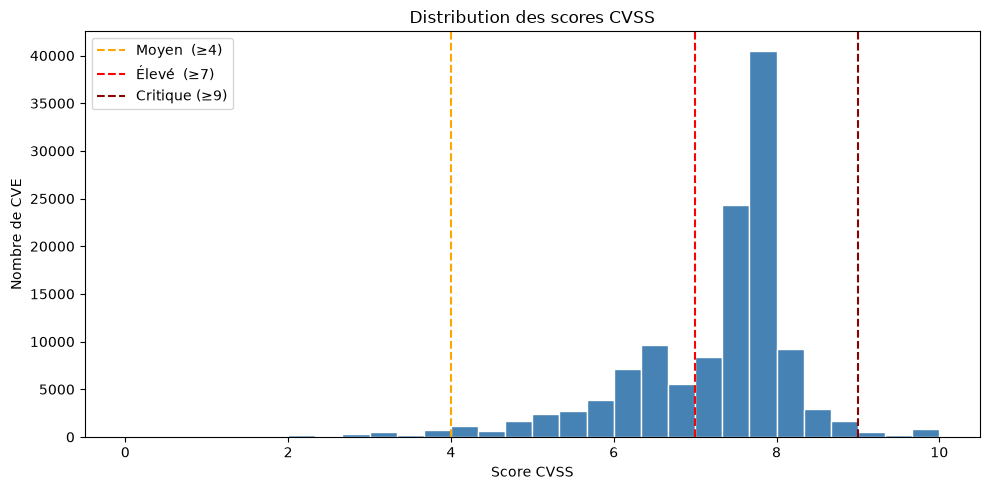

Moyenne : 7.22  |  Médiane : 7.59  |  Max : 10.0
CVE critiques (CVSS ≥ 9) : 1538 (1.2%)


In [51]:
plt.figure(figsize=(10, 5))
plt.hist(df_visu["CVSS prédite"].dropna(), bins=30, color="steelblue", edgecolor="white")
plt.axvline(x=4, color="orange",  linestyle="--", linewidth=1.5, label="Moyen  (≥4)")
plt.axvline(x=7, color="red",     linestyle="--", linewidth=1.5, label="Élevé  (≥7)")
plt.axvline(x=9, color="darkred", linestyle="--", linewidth=1.5, label="Critique (≥9)")
plt.title("Distribution des scores CVSS")
plt.xlabel("Score CVSS")
plt.ylabel("Nombre de CVE")
plt.legend()
plt.tight_layout()
plt.show()

# Stats rapides
cvss = df_visu["CVSS prédite"].dropna()
print(f"Moyenne : {cvss.mean():.2f}  |  Médiane : {cvss.median():.2f}  |  Max : {cvss.max():.1f}")
print(f"CVE critiques (CVSS ≥ 9) : {(cvss >= 9).sum()} ({(cvss >= 9).mean()*100:.1f}%)")


## 4. Courbe des scores EPSS

L'EPSS (0-1) estime la probabilité qu'une CVE soit exploitée. La plupart des CVE ont un EPSS très faible, mais quelques-unes sont très dangereuses.

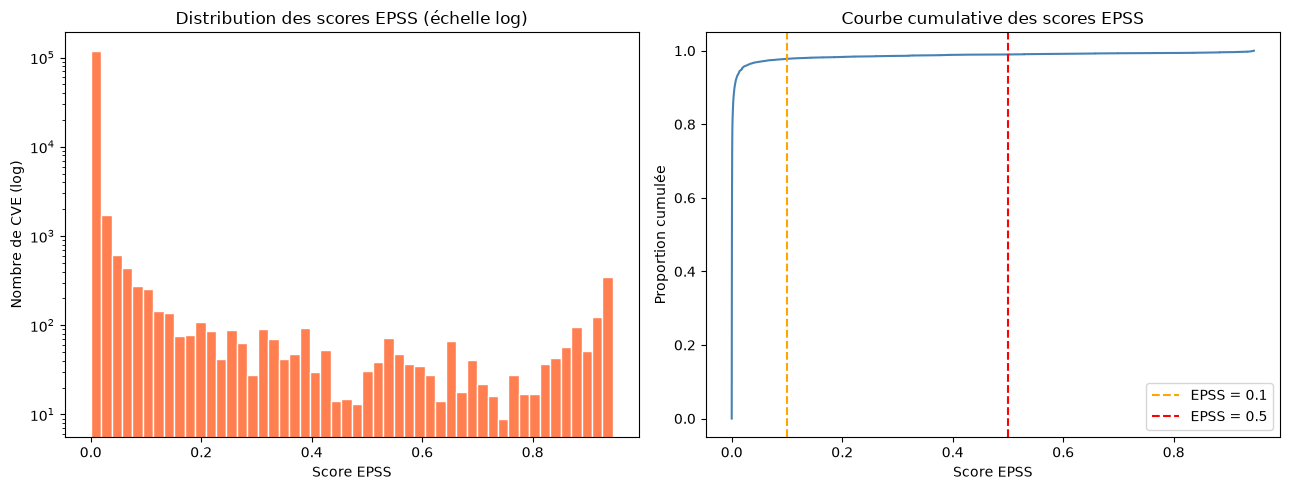

CVE avec EPSS ≥ 0.1 : 2765 (2.2%)
CVE avec EPSS ≥ 0.5 : 1278 (1.0%)


In [52]:
epss = df_visu["EPSS prédite"].dropna().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogramme (échelle log pour voir les petites valeurs)
axes[0].hist(epss, bins=50, color="coral", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Distribution des scores EPSS (échelle log)")
axes[0].set_xlabel("Score EPSS")
axes[0].set_ylabel("Nombre de CVE (log)")

# Courbe cumulative (CDF)
cdf = np.arange(1, len(epss) + 1) / len(epss)
axes[1].plot(epss.values, cdf, color="steelblue", linewidth=1.5)
axes[1].axvline(0.1, color="orange", linestyle="--", label="EPSS = 0.1")
axes[1].axvline(0.5, color="red",    linestyle="--", label="EPSS = 0.5")
axes[1].set_title("Courbe cumulative des scores EPSS")
axes[1].set_xlabel("Score EPSS")
axes[1].set_ylabel("Proportion cumulée")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"CVE avec EPSS ≥ 0.1 : {(epss >= 0.1).sum()} ({(epss >= 0.1).mean()*100:.1f}%)")
print(f"CVE avec EPSS ≥ 0.5 : {(epss >= 0.5).sum()} ({(epss >= 0.5).mean()*100:.1f}%)")


## 5. Nuage de points CVSS vs EPSS

Une CVE peut être grave (CVSS élevé) sans être exploitée activement, et vice versa. Ce graphe met en évidence cette distinction.

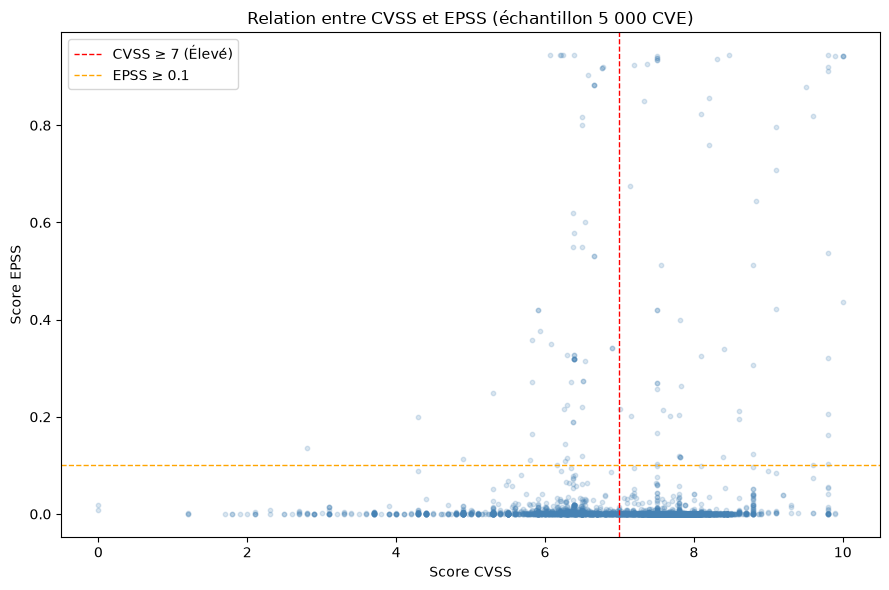

Corrélation CVSS / EPSS : 0.015
->Une faible corrélation confirme que gravité et exploitation sont deux dimensions indépendantes.


In [53]:
sample = df_visu[["CVSS prédite", "EPSS prédite"]].dropna().sample(n=5000, random_state=42)

plt.figure(figsize=(9, 6))
plt.scatter(sample["CVSS prédite"], sample["EPSS prédite"],
            alpha=0.2, s=10, color="steelblue")
plt.axvline(x=7, color="red",    linestyle="--", linewidth=1, label="CVSS ≥ 7 (Élevé)")
plt.axhline(y=0.1, color="orange", linestyle="--", linewidth=1, label="EPSS ≥ 0.1")
plt.title("Relation entre CVSS et EPSS (échantillon 5 000 CVE)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.legend()
plt.tight_layout()
plt.show()


corr = df_visu[["CVSS prédite", "EPSS prédite"]].corr().iloc[0, 1]
print(f"Corrélation CVSS / EPSS : {corr:.3f}")
print("->Une faible corrélation confirme que gravité et exploitation sont deux dimensions indépendantes.")


## 6. Heatmap des corrélations

On visualise les corrélations entre les scores numériques avec `matplotlib` (pas besoin de seaborn).

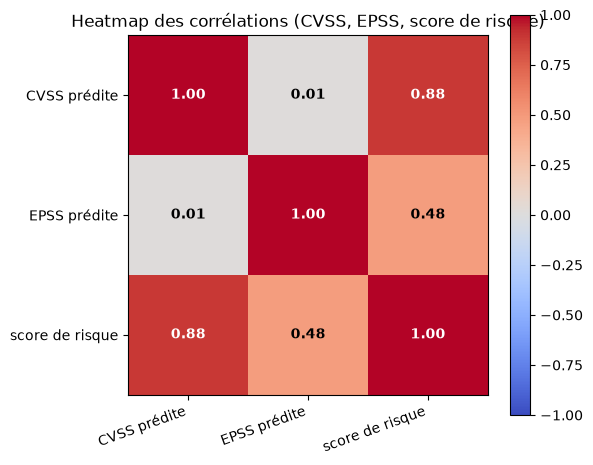

In [54]:
num_cols = ["CVSS prédite", "EPSS prédite", "score de risque"]
corr_matrix = df_visu[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(num_cols)))
ax.set_yticks(range(len(num_cols)))
ax.set_xticklabels(num_cols, rotation=20, ha="right")
ax.set_yticklabels(num_cols)

for i in range(len(num_cols)):
    for j in range(len(num_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}",
                ha="center", va="center", fontweight="bold",
                color="white" if abs(corr_matrix.values[i, j]) > 0.5 else "black")

ax.set_title("Heatmap des corrélations (CVSS, EPSS, score de risque)")
plt.tight_layout()
plt.show()


## 7. Alertes vs Avis

Les **Alertes** concernent des vulnérabilités activement exploitées — on s'attend donc à un CVSS moyen plus élevé.

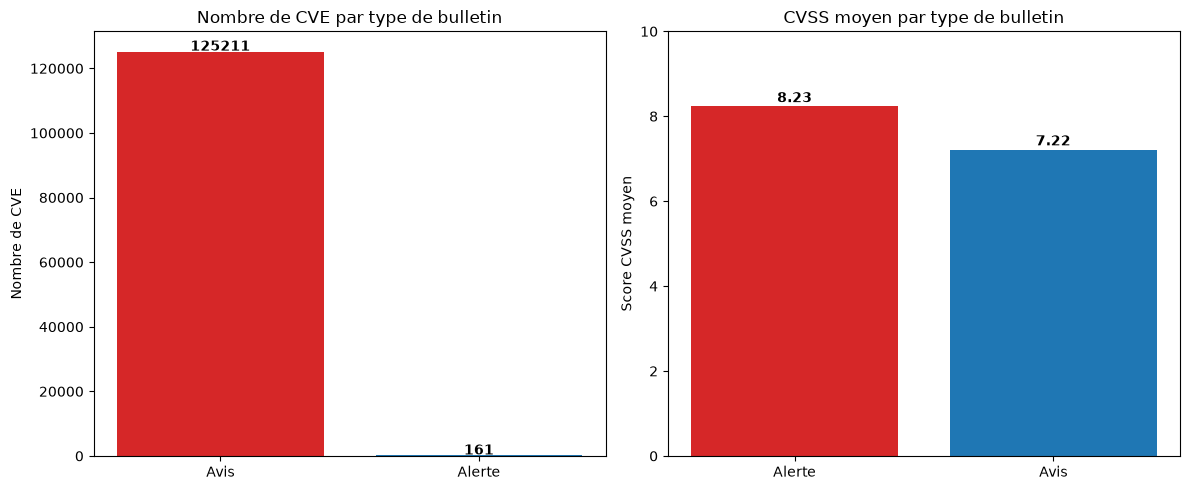

In [55]:
type_counts  = df_visu["Type"].value_counts()
cvss_by_type = df_visu.groupby("Type")["CVSS prédite"].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Nombre de CVE
axes[0].bar(type_counts.index, type_counts.values, color=["#d62728", "#1f77b4"])
for i, val in enumerate(type_counts.values):
    axes[0].text(i, val + 300, str(val), ha="center", fontweight="bold")
axes[0].set_title("Nombre de CVE par type de bulletin")
axes[0].set_ylabel("Nombre de CVE")

# CVSS moyen
axes[1].bar(cvss_by_type.index, cvss_by_type.values, color=["#d62728", "#1f77b4"])
for i, val in enumerate(cvss_by_type.values):
    axes[1].text(i, val + 0.1, f"{val:.2f}", ha="center", fontweight="bold")
axes[1].set_title("CVSS moyen par type de bulletin")
axes[1].set_ylabel("Score CVSS moyen")
axes[1].set_ylim(0, 10)

plt.tight_layout()
plt.show()


## 8. Éditeurs les plus affectés

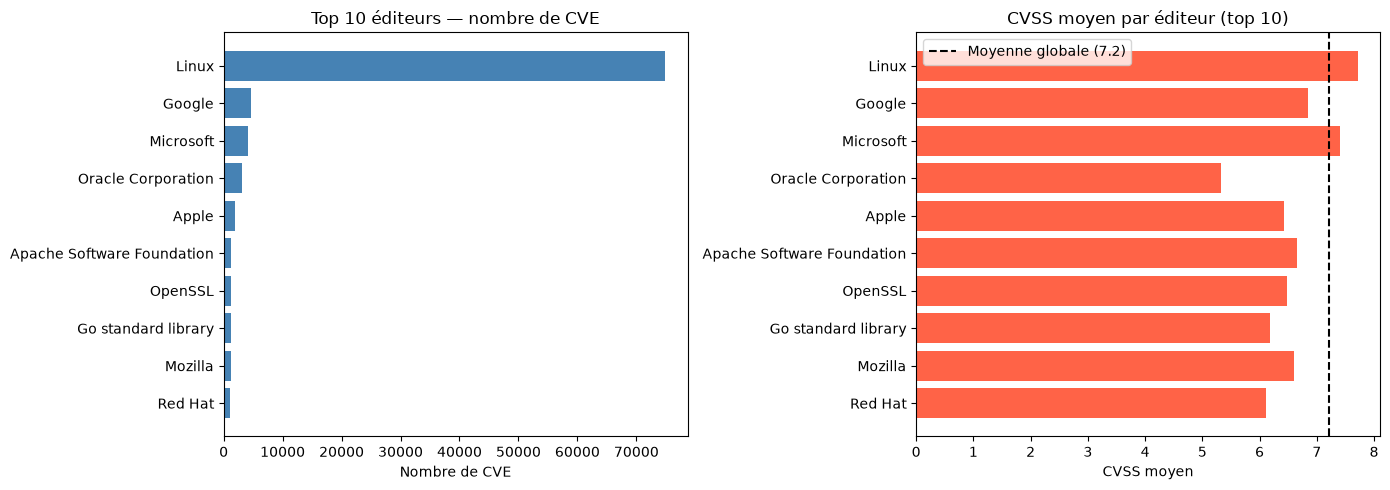

In [56]:
top_editeurs = df_visu["Editeur_clean"].value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart nombre de CVE
axes[0].barh(top_editeurs.index[::-1], top_editeurs.values[::-1], color="steelblue")
axes[0].set_title("Top 10 éditeurs — nombre de CVE")
axes[0].set_xlabel("Nombre de CVE")

# CVSS moyen par éditeur (top 10)
cvss_editeur = (df_visu[df_visu["Editeur_clean"].isin(top_editeurs.index)]
                .groupby("Editeur_clean")["CVSS prédite"]
                .mean()
                .reindex(top_editeurs.index))
axes[1].barh(cvss_editeur.index[::-1], cvss_editeur.values[::-1], color="tomato")
axes[1].axvline(df_visu["CVSS prédite"].mean(), color="black", linestyle="--",
                label=f"Moyenne globale ({df_visu['CVSS prédite'].mean():.1f})")
axes[1].set_title("CVSS moyen par éditeur (top 10)")
axes[1].set_xlabel("CVSS moyen")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Boxplot des scores CVSS par éditeur

Le boxplot montre la dispersion des scores CVSS pour chaque éditeur, pas seulement la moyenne.

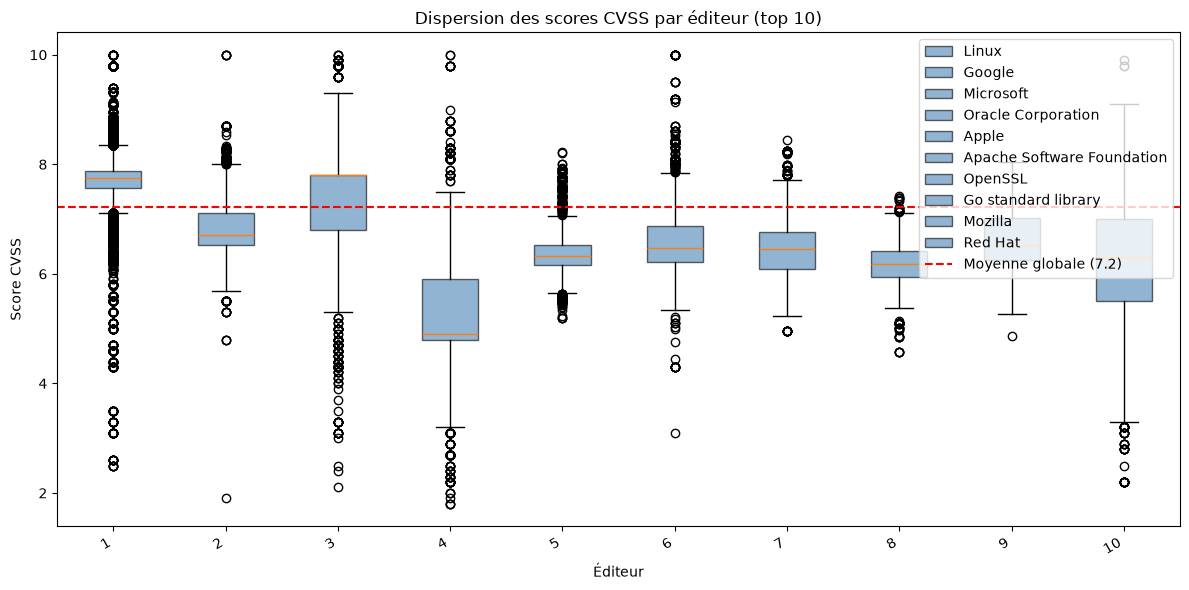

In [57]:
top10_noms = df_visu["Editeur_clean"].value_counts().head(10).index.tolist()
df_box = df_visu[df_visu["Editeur_clean"].isin(top10_noms)]

# Préparer les données pour le boxplot matplotlib
data_box = [df_box[df_box["Editeur_clean"] == e]["CVSS prédite"].dropna().values
            for e in top10_noms]

fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot(data_box, label=top10_noms, patch_artist=True,
           boxprops=dict(facecolor="steelblue", alpha=0.6))
ax.axhline(df_visu["CVSS prédite"].mean(), color="red", linestyle="--",
           label=f"Moyenne globale ({df_visu['CVSS prédite'].mean():.1f})")
ax.set_title("Dispersion des scores CVSS par éditeur (top 10)")
ax.set_ylabel("Score CVSS")
ax.set_xlabel("Éditeur")
plt.xticks(rotation=30, ha="right")
ax.legend()
plt.tight_layout()
plt.show()


## 10. Produits les plus vulnérables

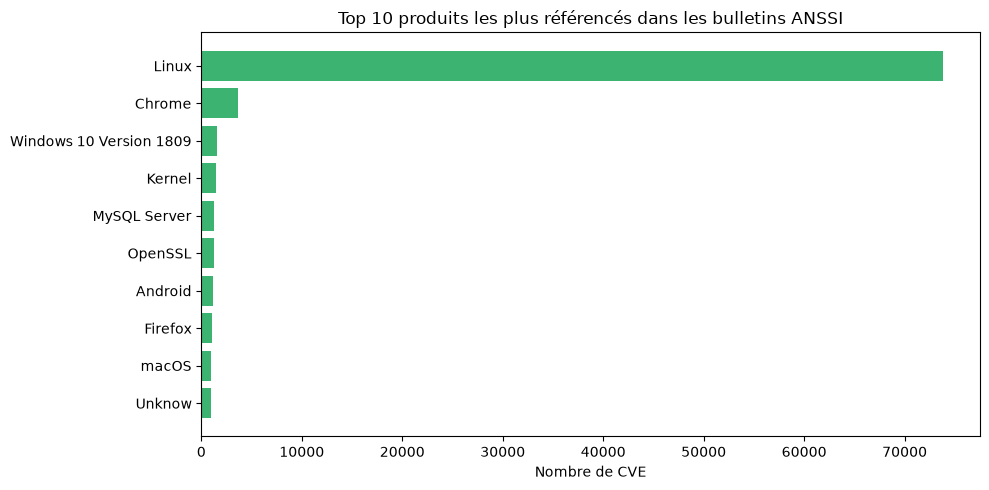

In [58]:
top_produits = df_visu["Produit_clean"].value_counts().head(10)

plt.figure(figsize=(10, 5))
plt.barh(top_produits.index[::-1], top_produits.values[::-1], color="mediumseagreen")
plt.title("Top 10 produits les plus référencés dans les bulletins ANSSI")
plt.xlabel("Nombre de CVE")
plt.tight_layout()
plt.show()


## 11. Évolution temporelle des vulnérabilités

On trace l'évolution mensuelle du nombre de CVE détectées et la courbe cumulative.

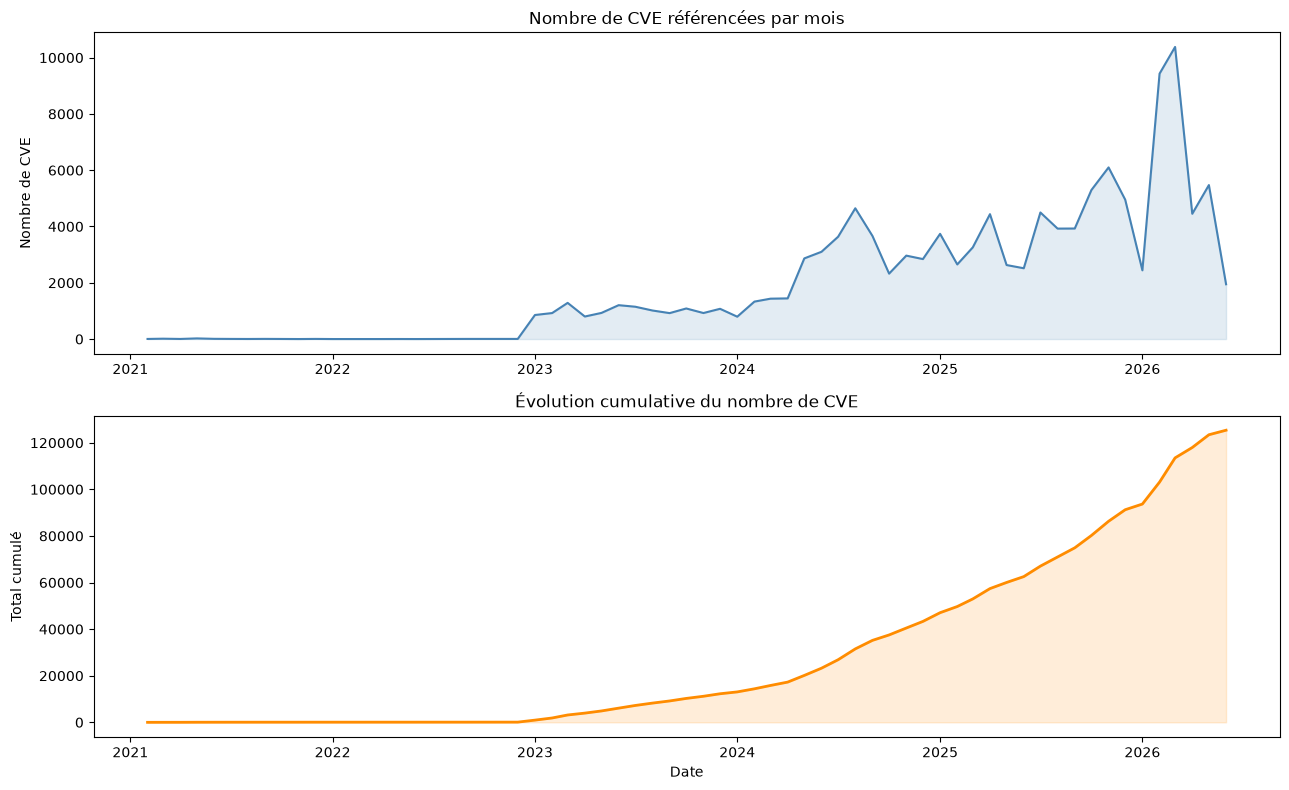

In [59]:
df_time = df_visu.dropna(subset=["Date"]).copy()
monthly = df_time.groupby(df_time["Date"].dt.to_period("M")).size()
monthly.index = monthly.index.to_timestamp()
cumul = monthly.cumsum()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))

axes[0].plot(monthly.index, monthly.values, color="steelblue", linewidth=1.5)
axes[0].fill_between(monthly.index, monthly.values, alpha=0.15, color="steelblue")
axes[0].set_title("Nombre de CVE référencées par mois")
axes[0].set_ylabel("Nombre de CVE")

axes[1].plot(cumul.index, cumul.values, color="darkorange", linewidth=2)
axes[1].fill_between(cumul.index, cumul.values, alpha=0.15, color="darkorange")
axes[1].set_title("Évolution cumulative du nombre de CVE")
axes[1].set_ylabel("Total cumulé")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()


## 12. Nombre de vulnérabilités par éditeur — Alertes vs Avis

On distingue pour chaque éditeur la part d'Alertes (exploitation active) vs d'Avis.

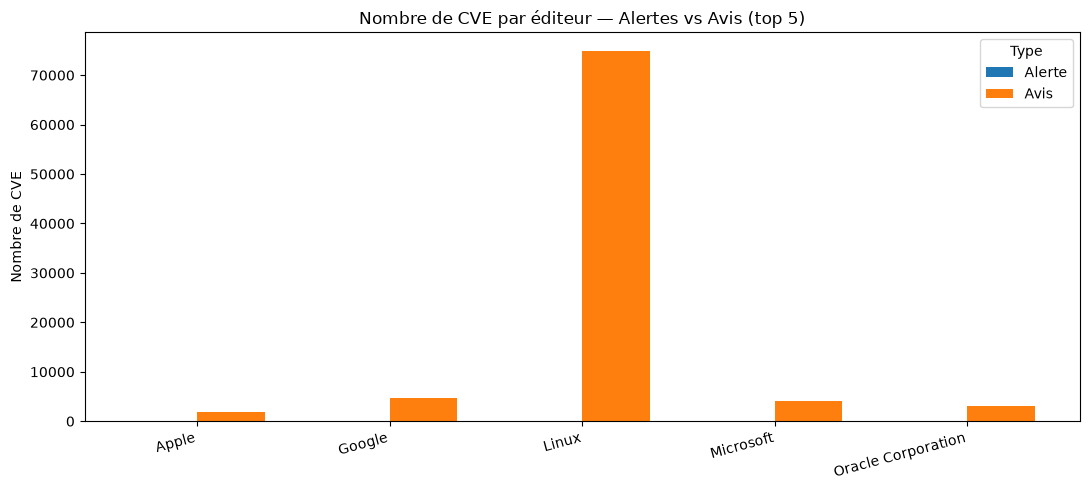

In [60]:
top5_noms = df_visu["Editeur_clean"].value_counts().head(5).index.tolist()
df_type = df_visu[df_visu["Editeur_clean"].isin(top5_noms)]
pivot = df_type.groupby(["Editeur_clean", "Type"]).size().unstack(fill_value=0)

x = np.arange(len(pivot))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
for i, col in enumerate(pivot.columns):
    offset = (i - len(pivot.columns) / 2 + 0.5) * width
    bars = ax.bar(x + offset, pivot[col], width, label=col)

ax.set_title("Nombre de CVE par éditeur — Alertes vs Avis (top 5)")
ax.set_xticks(x)
ax.set_xticklabels(pivot.index, rotation=15, ha="right")
ax.set_ylabel("Nombre de CVE")
ax.legend(title="Type")
plt.tight_layout()
plt.show()


## 13. Top 20 CVE les plus dangereuses (CVSS × EPSS)

On combine CVSS et EPSS pour identifier les CVE qui sont à la fois graves **et** activement exploitées.

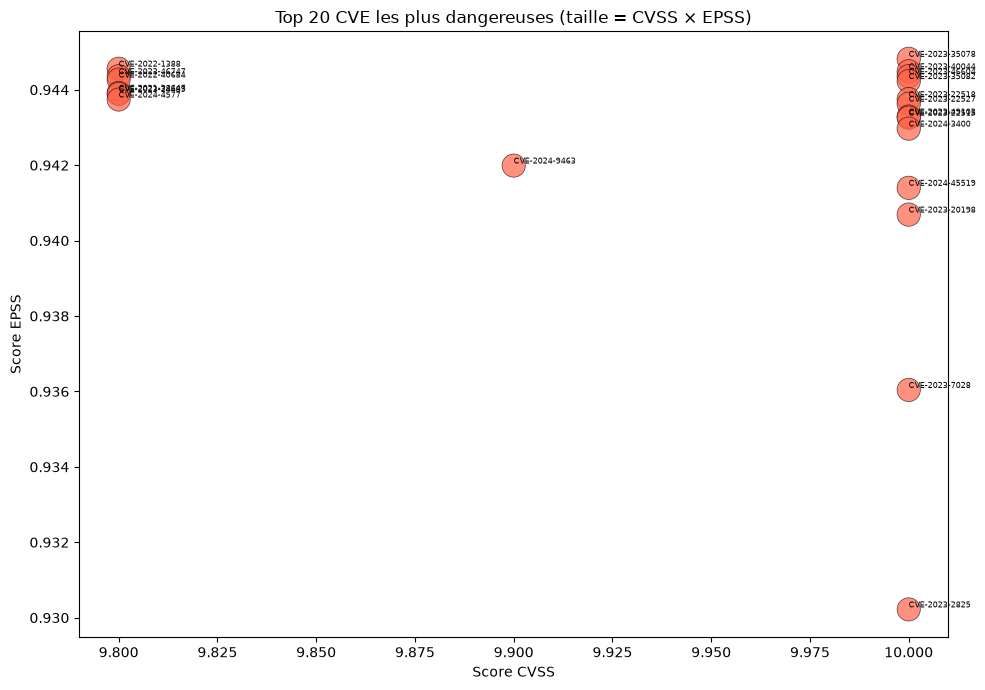

,CVE,Produit_clean,CVSS prédite,EPSS prédite,danger_score
0,CVE-2023-35078,Endpoint Manager Mobile,10.0,0.94482,9.448200
1,CVE-2023-40044,WS_FTP Server,10.0,0.94449,9.444900
2,CVE-2023-46604,Apache ActiveMQ,10.0,0.94436,9.443600
3,CVE-2023-35082,EPMM,10.0,0.94423,9.442300
4,CVE-2023-22518,Confluence Data Center,10.0,0.94375,9.437500
5,CVE-2023-22527,Confluence Data Center,10.0,0.94363,9.436300
6,CVE-2023-49103,NaN,10.0,0.94329,9.432900
7,CVE-2023-22515,Confluence Data Center,10.0,0.94326,9.432600
8,CVE-2024-3400,PAN-OS,10.0,0.94297,9.429700
9,CVE-2024-45519,NaN,10.0,0.94140,9.414000


In [61]:
df_top = (df_visu[["CVE", "Produit_clean", "CVSS prédite", "EPSS prédite", "CVSS", "EPSS"]]
          .dropna(subset=["CVSS", "EPSS"])
          .drop_duplicates("CVE")
          .copy())
df_top["danger_score"] = df_top["CVSS prédite"] * df_top["EPSS prédite"]
top20 = df_top.nlargest(20, "danger_score")

plt.figure(figsize=(10, 7))
plt.scatter(
    top20["CVSS prédite"], top20["EPSS prédite"],
    s=top20["danger_score"] * 30,
    color="tomato", alpha=0.7, edgecolors="black", linewidth=0.5
)
for _, row in top20.iterrows():
    plt.annotate(row["CVE"],
                 (row["CVSS prédite"], row["EPSS prédite"]),
                 fontsize=6, ha="left", va="bottom")
plt.title("Top 20 CVE les plus dangereuses (taille = CVSS × EPSS)")
plt.xlabel("Score CVSS")
plt.ylabel("Score EPSS")
plt.tight_layout()
plt.show()

top20[["CVE", "Produit_clean", "CVSS prédite", "EPSS prédite", "danger_score"]].reset_index(drop=True)


## 14. Synthèse et conclusions

Les visualisations précédentes permettent de tirer plusieurs conclusions :

- **CVSS et EPSS sont faiblement corrélés** : une vulnérabilité grave techniquement n'est pas forcément exploitée activement. Il faut combiner les deux indicateurs pour prioriser efficacement.
- **Les Alertes ANSSI** (exploitation active) ont un CVSS moyen nettement plus élevé que les Avis, ce qui est cohérent avec leur nature urgente.
- **La majorité des CVE** a un EPSS très faible (< 0.01), mais une minorité à EPSS élevé concentre le risque réel — la courbe cumulative EPSS l'illustre clairement.
- **Linux et Google** dominent les éditeurs en volume de CVE, mais leur CVSS moyen n'est pas nécessairement le plus élevé.
- **Le `risk_score` (CVSS × EPSS)** est un bon indicateur synthétique pour prioriser les actions de remédiation.


# Sauvegarde finale :

In [63]:
df.to_csv("./data/dataset_complet.csv",sep=";", index=False)